In [2]:
import matplotlib.pyplot as plt
import numpy as np

from model_ranking.utils import load_h5


In [10]:
H_data_path = "/scratch/talks/data/Hmito/test_converted.h5"
H_data_gt = load_h5(H_data_path, "labels", roi=[[0,150],[0,1280], [0,1280]])

In [4]:
EtoH_none_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_Hmito_gap/feature_perturbation_consistency/FP_3/E_model_NA2/norm_Normalize/none/predictions/test_converted_predictions.h5"
EtoH_preds = load_h5(EtoH_none_path, "predictions")
EtoH_patch_indexes = load_h5(EtoH_none_path, "patch_index")

In [11]:
EtoH_f1_Scores = load_h5(EtoH_none_path, "hard_f1")

In [13]:
ids_zero = np.where(EtoH_f1_Scores[:, 1] == 0)[0]
print(f"Number of patches with zero F1 score: {len(ids_zero)}")

Number of patches with zero F1 score: 3241


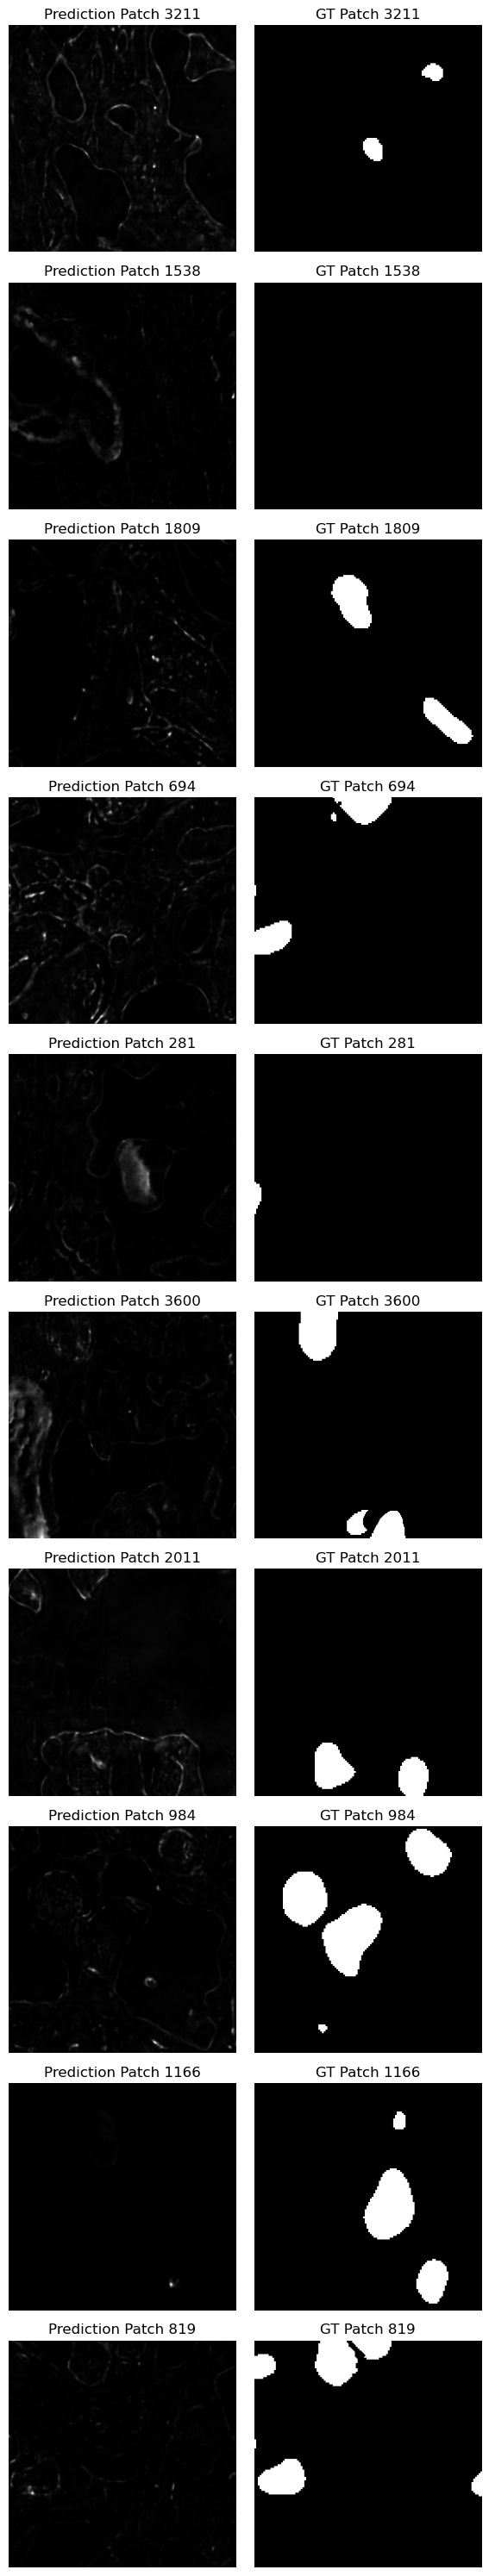

In [15]:
# Set random seed for reproducibility
np.random.seed(10)

# Randomly select 10 patch indices from ids_zero
sample_indices = np.random.choice(ids_zero, size=10, replace=False)

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(6, 3 * len(sample_indices)))

for i, idx in enumerate(sample_indices):
    # Get patch coordinates
    z, y, x = EtoH_patch_indexes[idx]
    # Extract prediction and ground truth patch
    pred_patch = EtoH_preds[idx, 0, 0]
    gt_patch = H_data_gt[z[0]:z[1], y[0]:y[1], x[0]:x[1]]

    # Plot prediction
    axes[i, 0].imshow(pred_patch.squeeze(), cmap='gray')
    axes[i, 0].set_title(f'Prediction Patch {idx}')
    axes[i, 0].axis('off')

    # Plot ground truth
    axes[i, 1].imshow(gt_patch.squeeze(), cmap='gray')
    axes[i, 1].set_title(f'GT Patch {idx}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

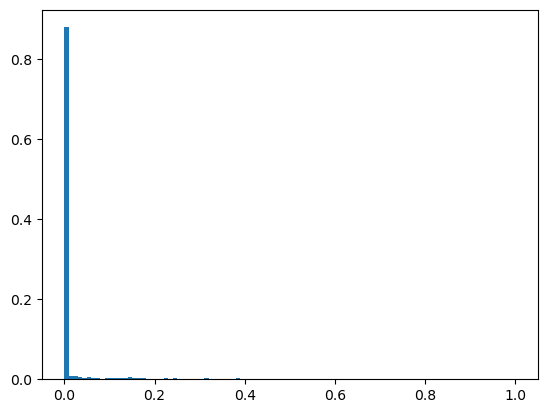

In [12]:
plt.hist(EtoH_f1_Scores[:, 1], bins=100, range=(0, 1), weights=np.ones(len(EtoH_f1_Scores[:, 1])) / len(EtoH_f1_Scores[:, 1]))
plt.show()

# Per Patch Consistency vs Performance

In [18]:
from typing import List, Dict, Optional
from pathlib import Path

from model_ranking.utils import (
    get_output_paths,
    load_h5,
)

/tmp/ipykernel_4149064/178635249.py:61: RuntimeWarning: Mean of empty slice
  consis_score_PP = np.nanmean(consis_score_direct, axis=tuple(range(1, consis_score_direct.ndim)))


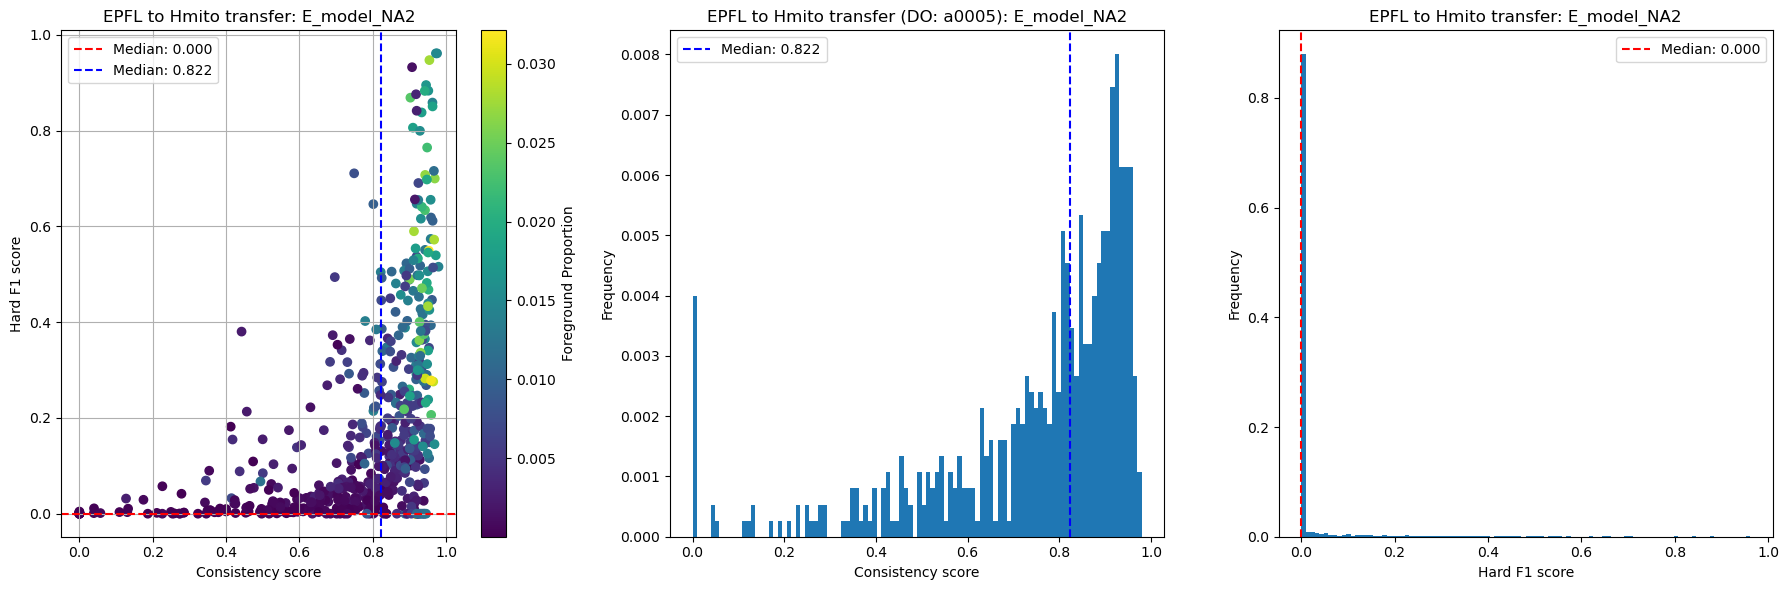

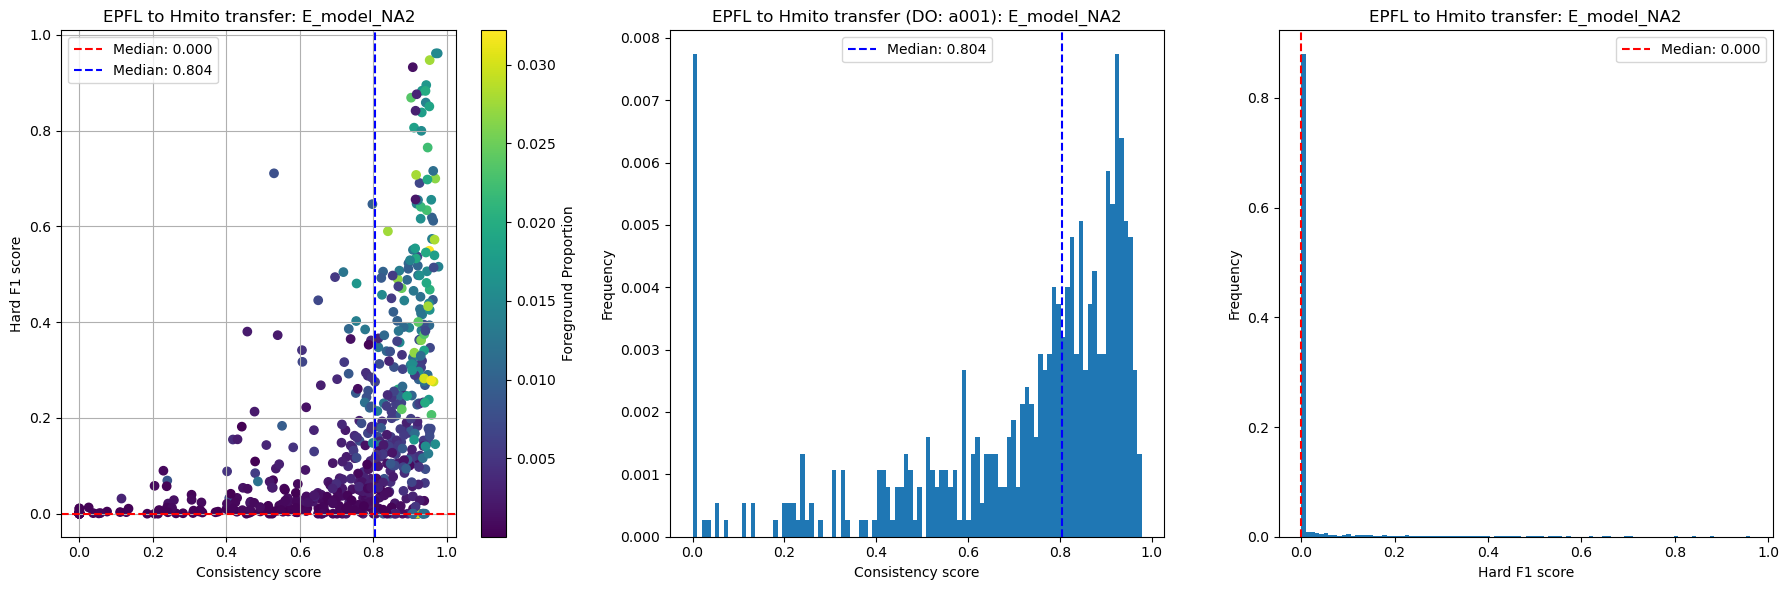

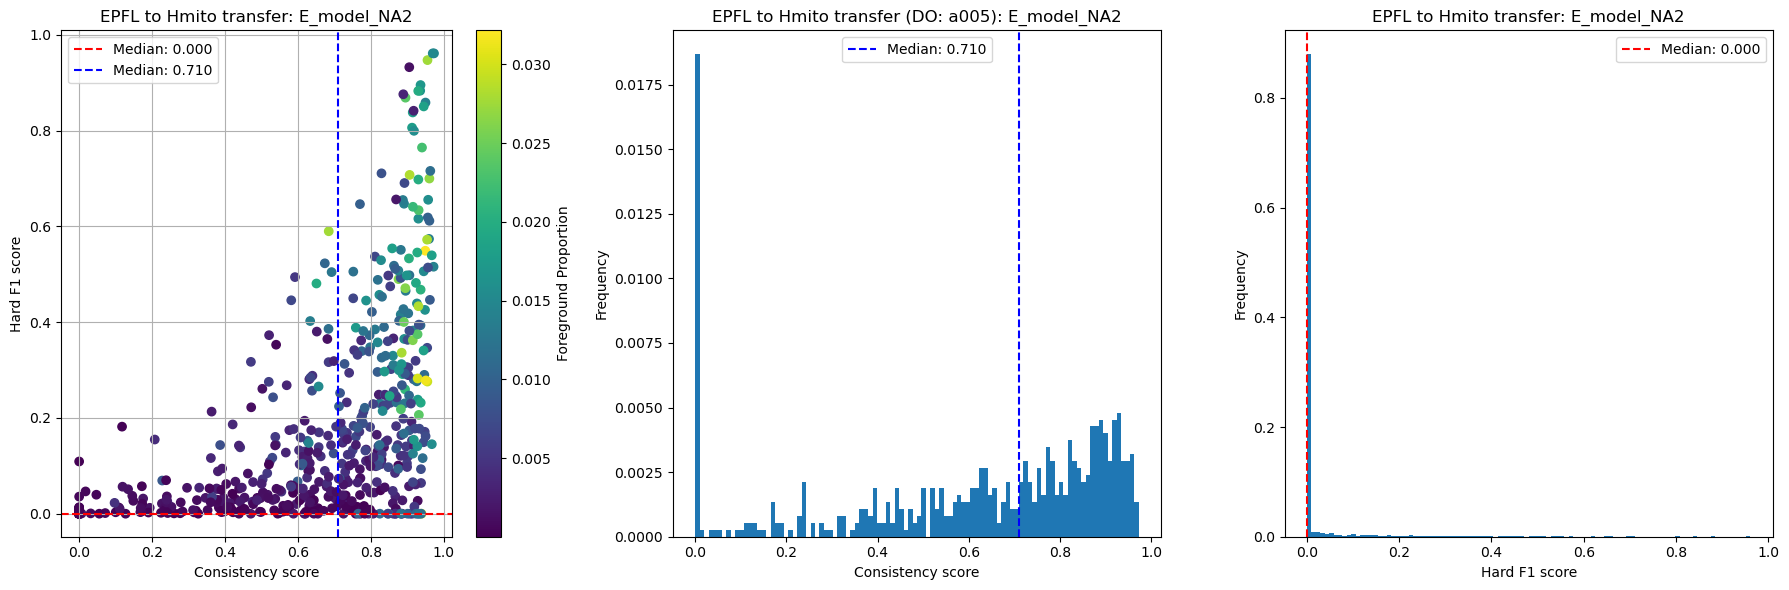

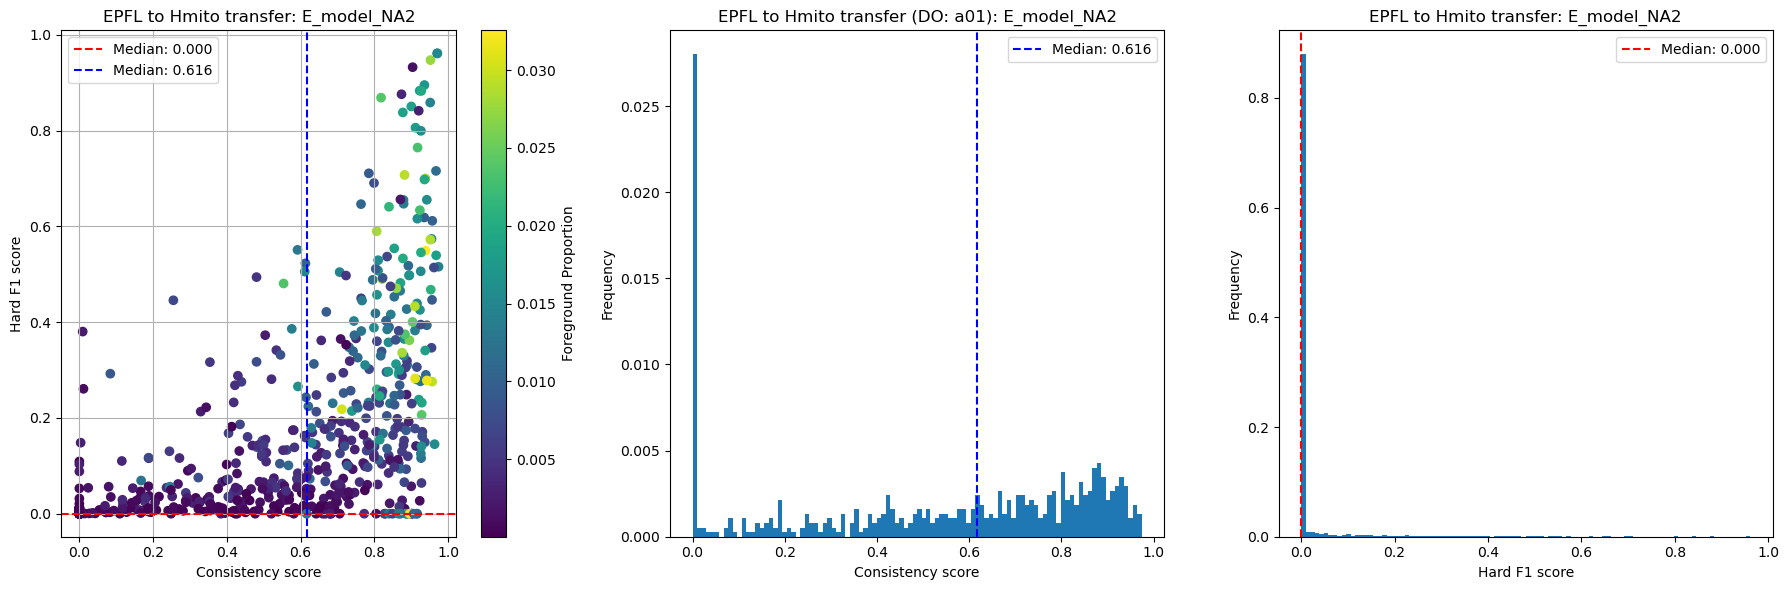

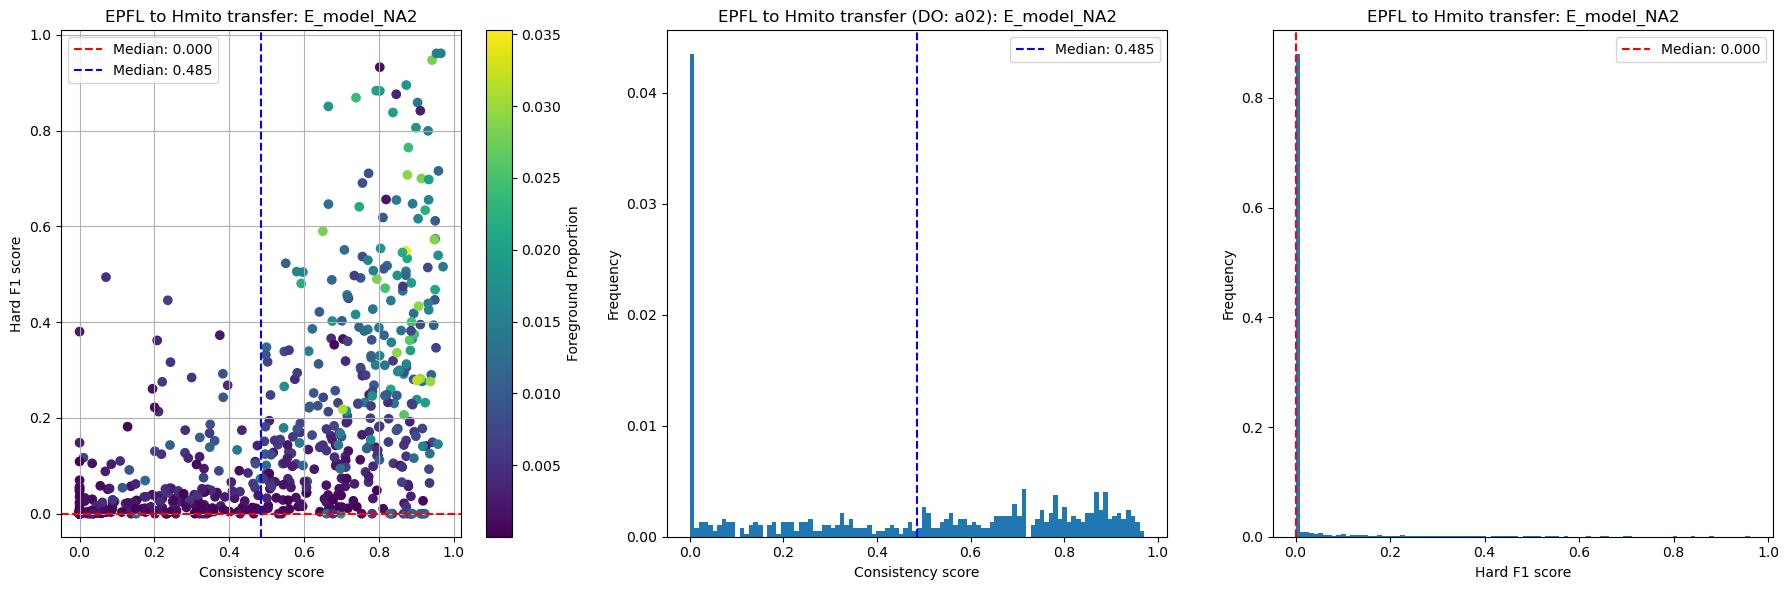

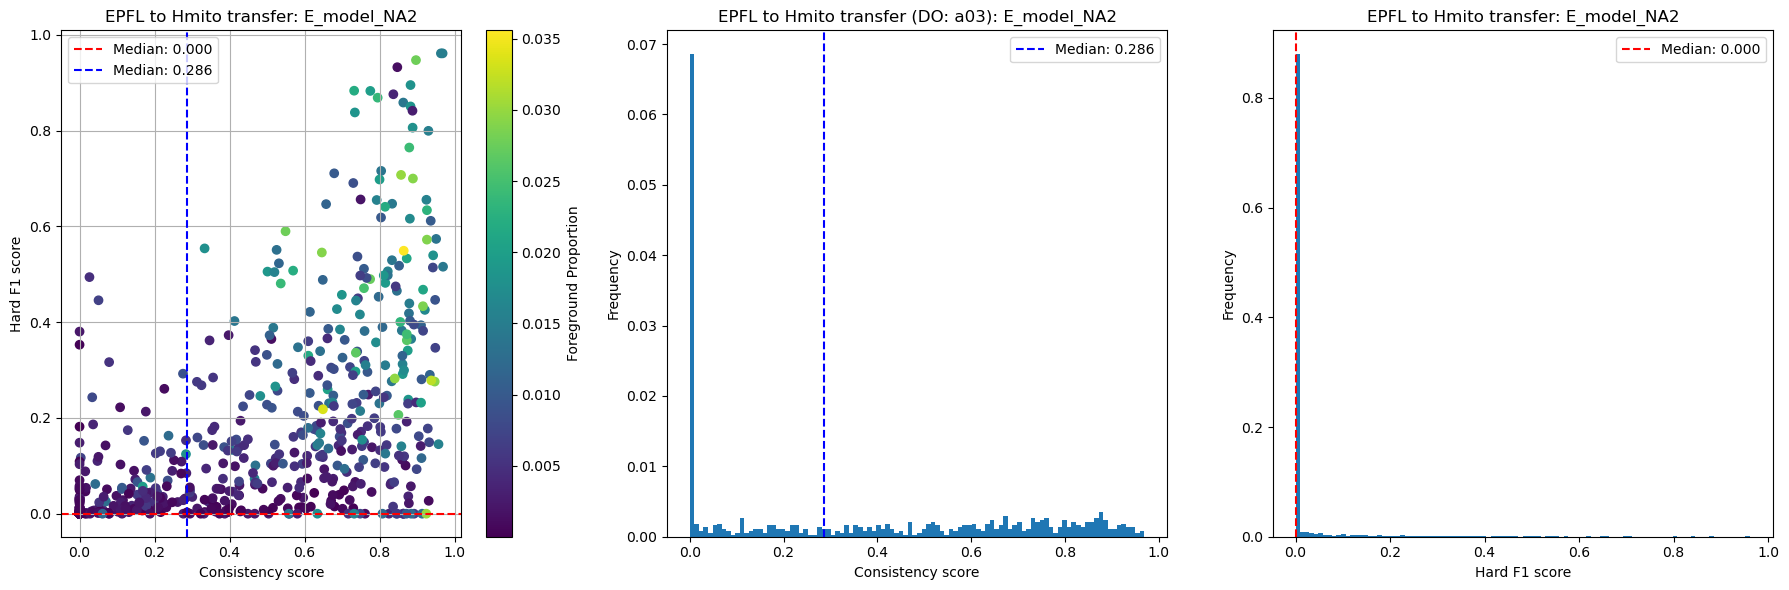

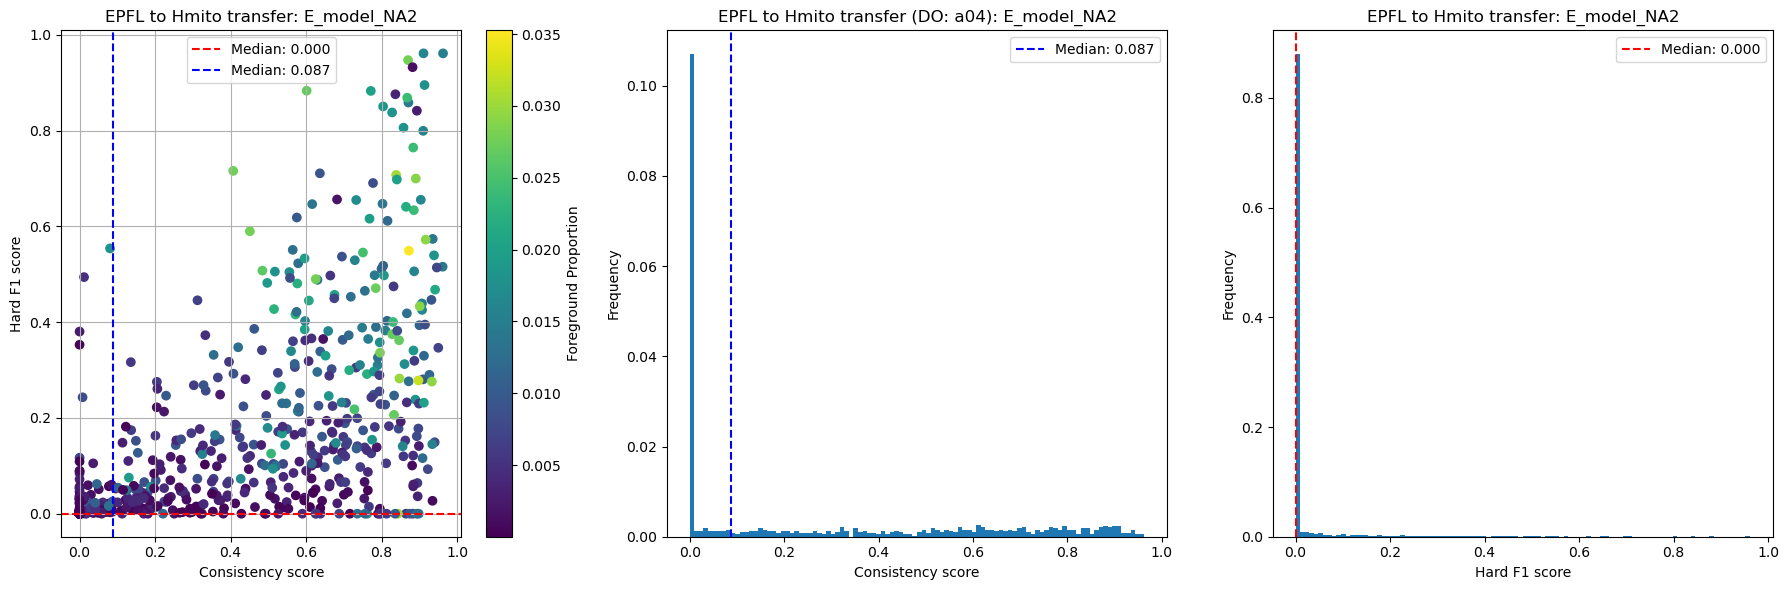

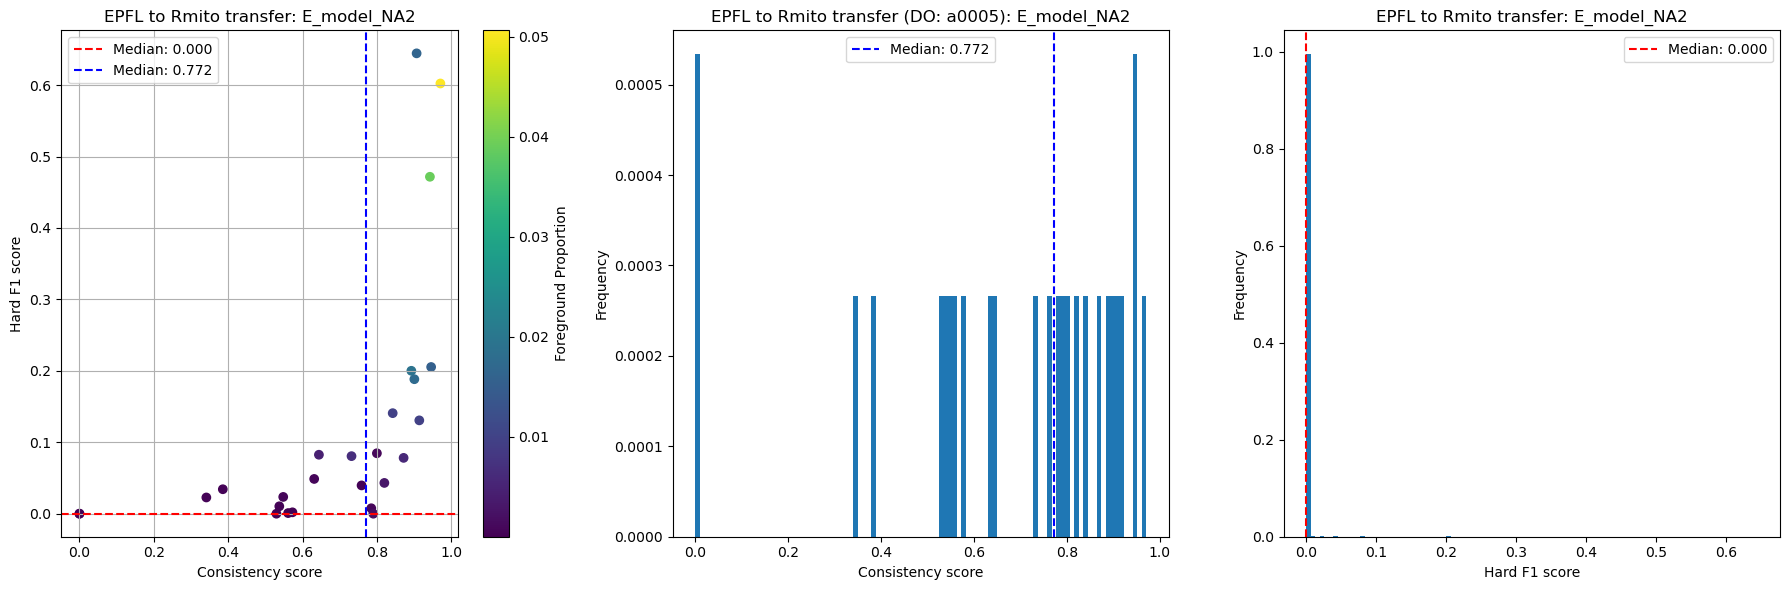

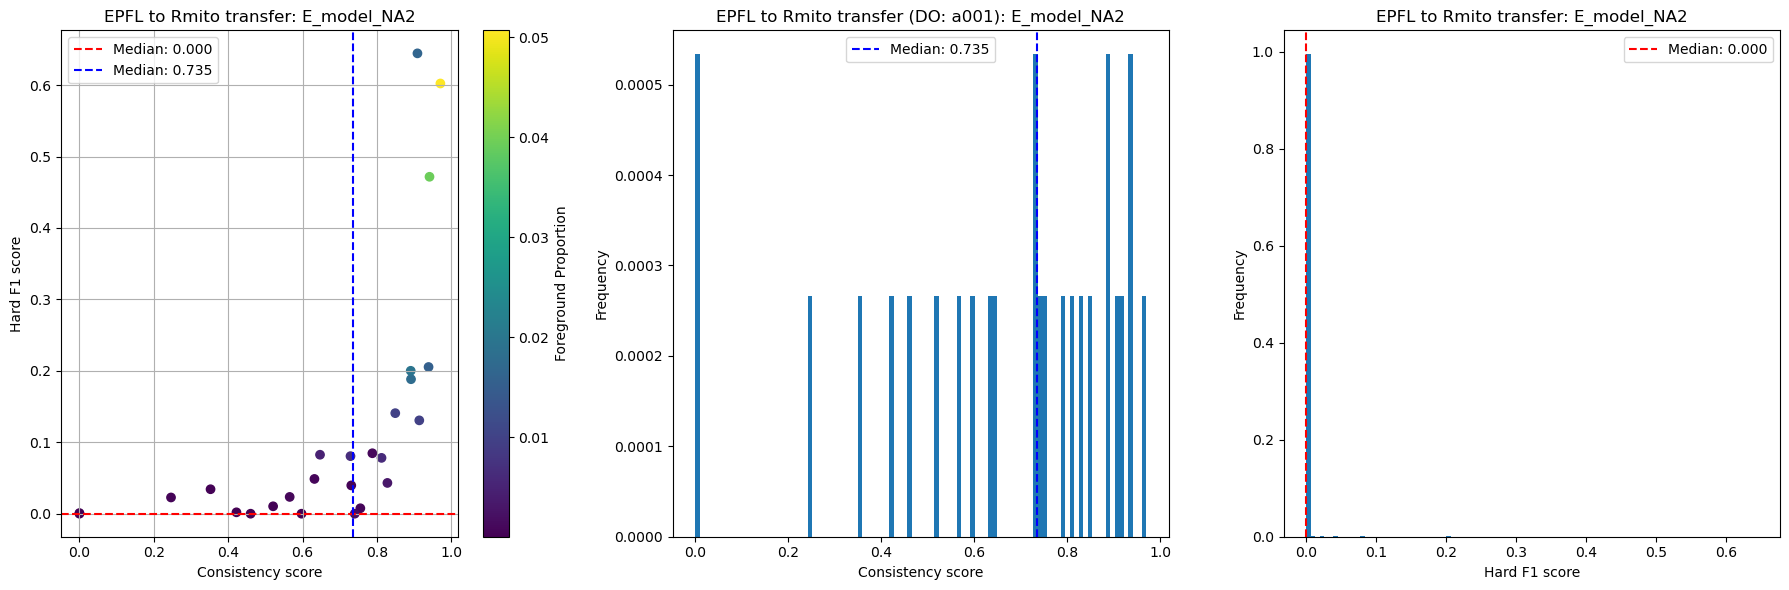

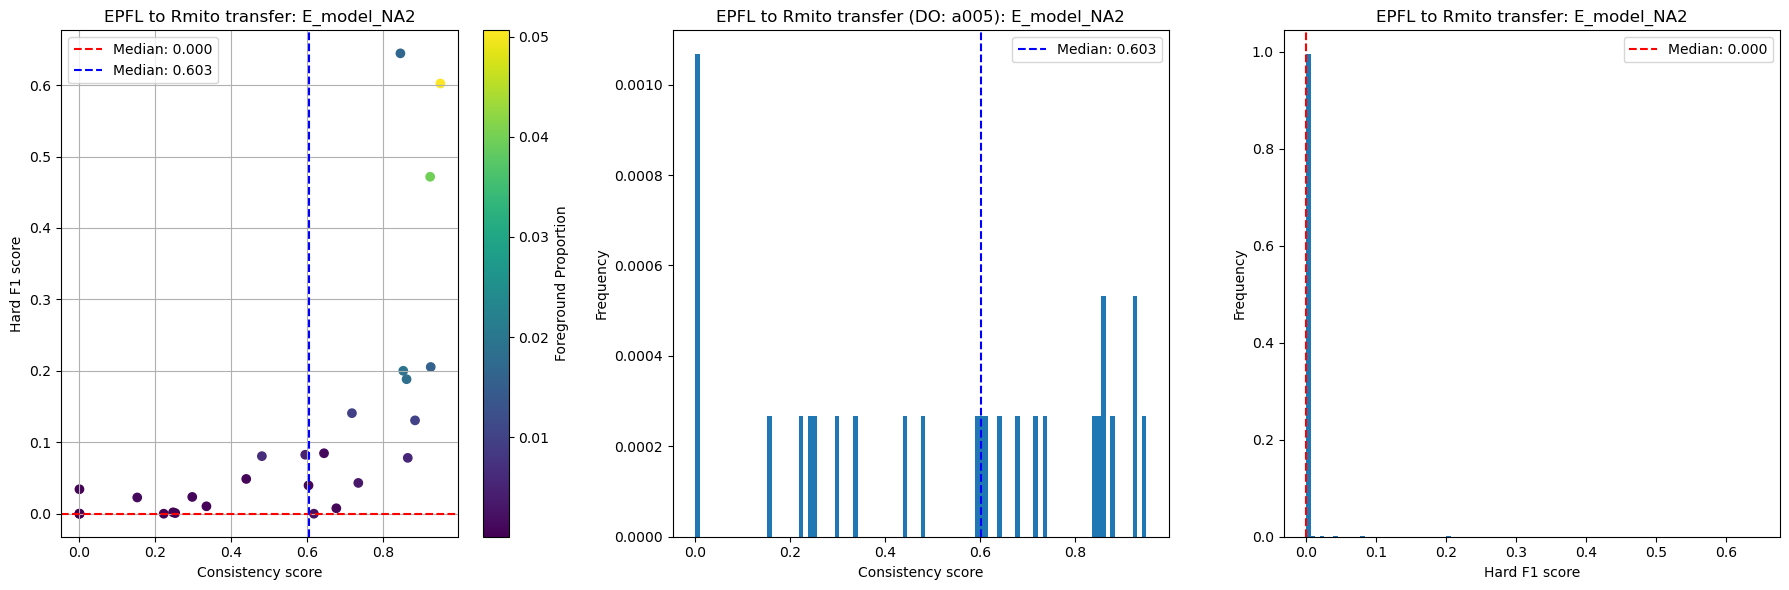

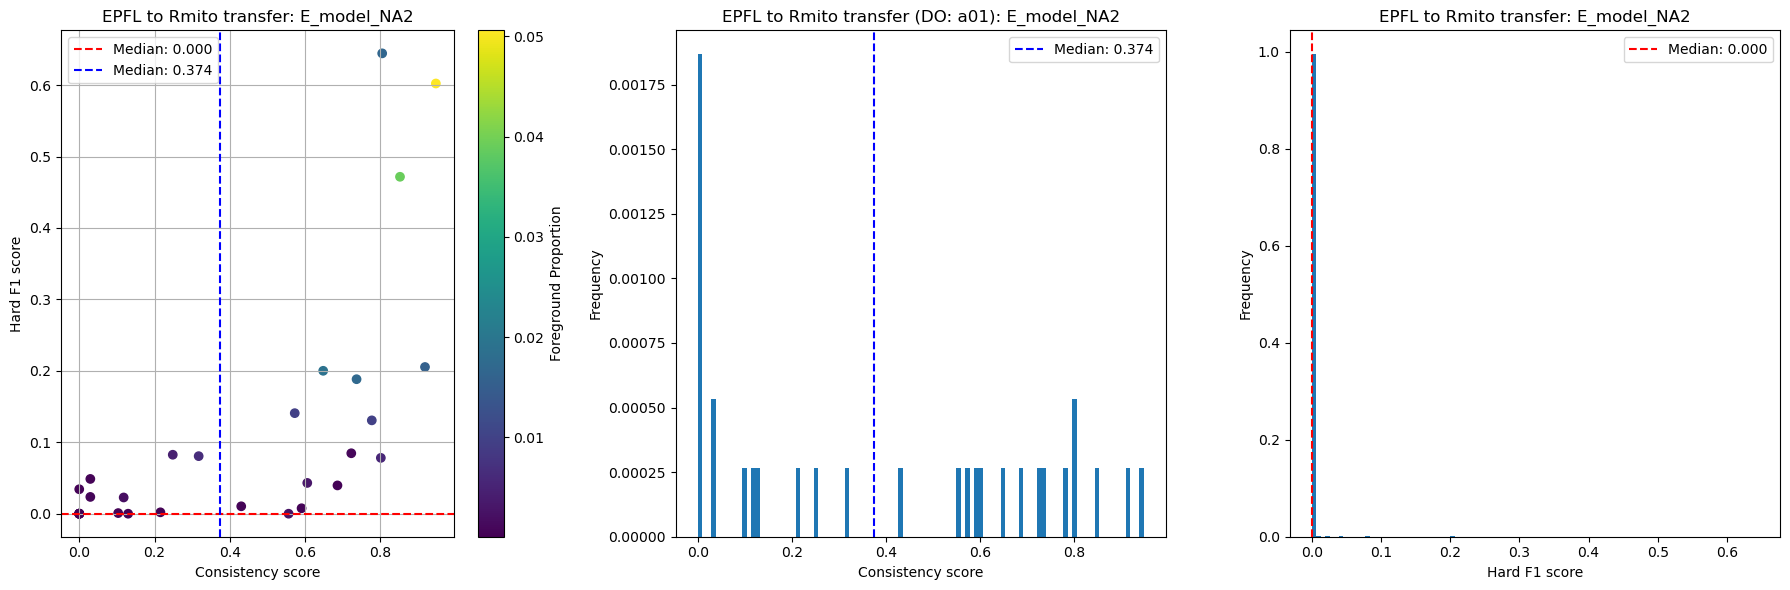

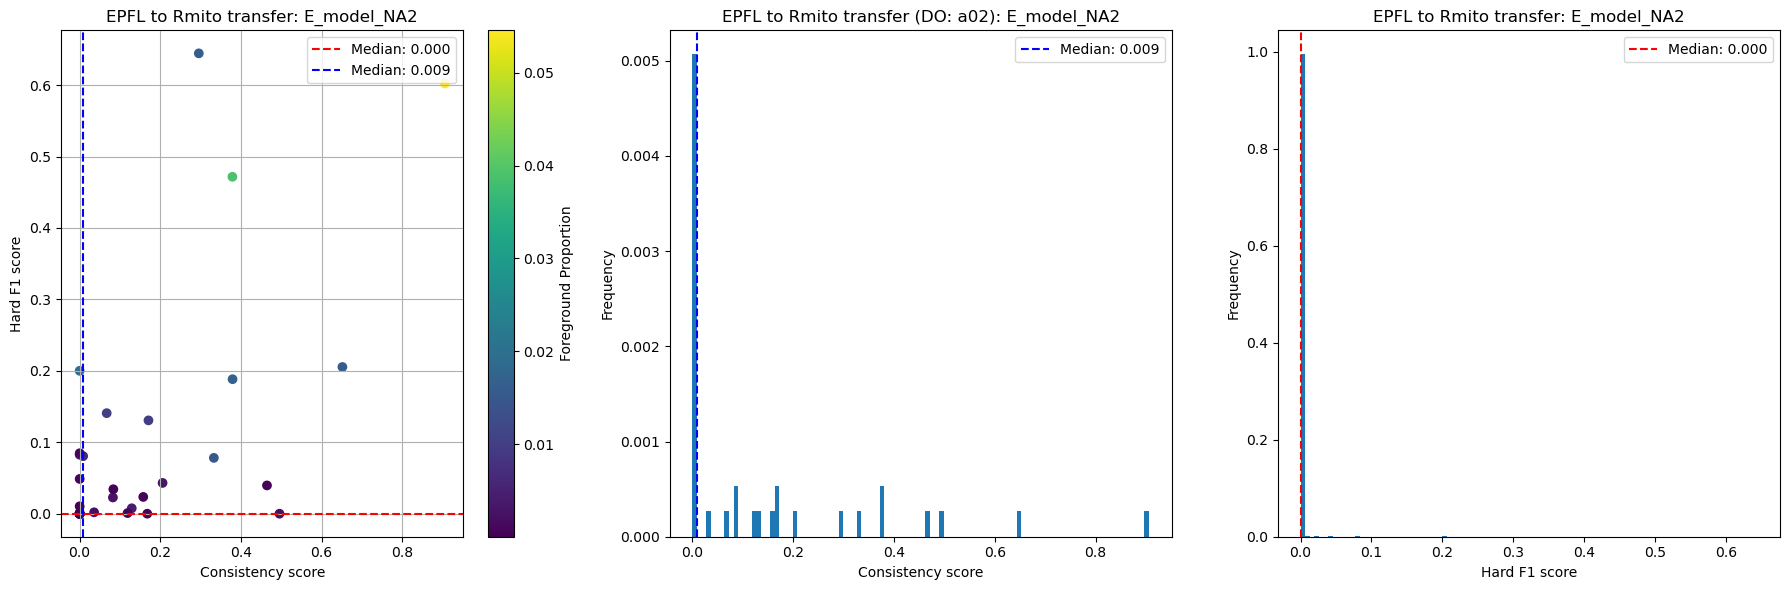

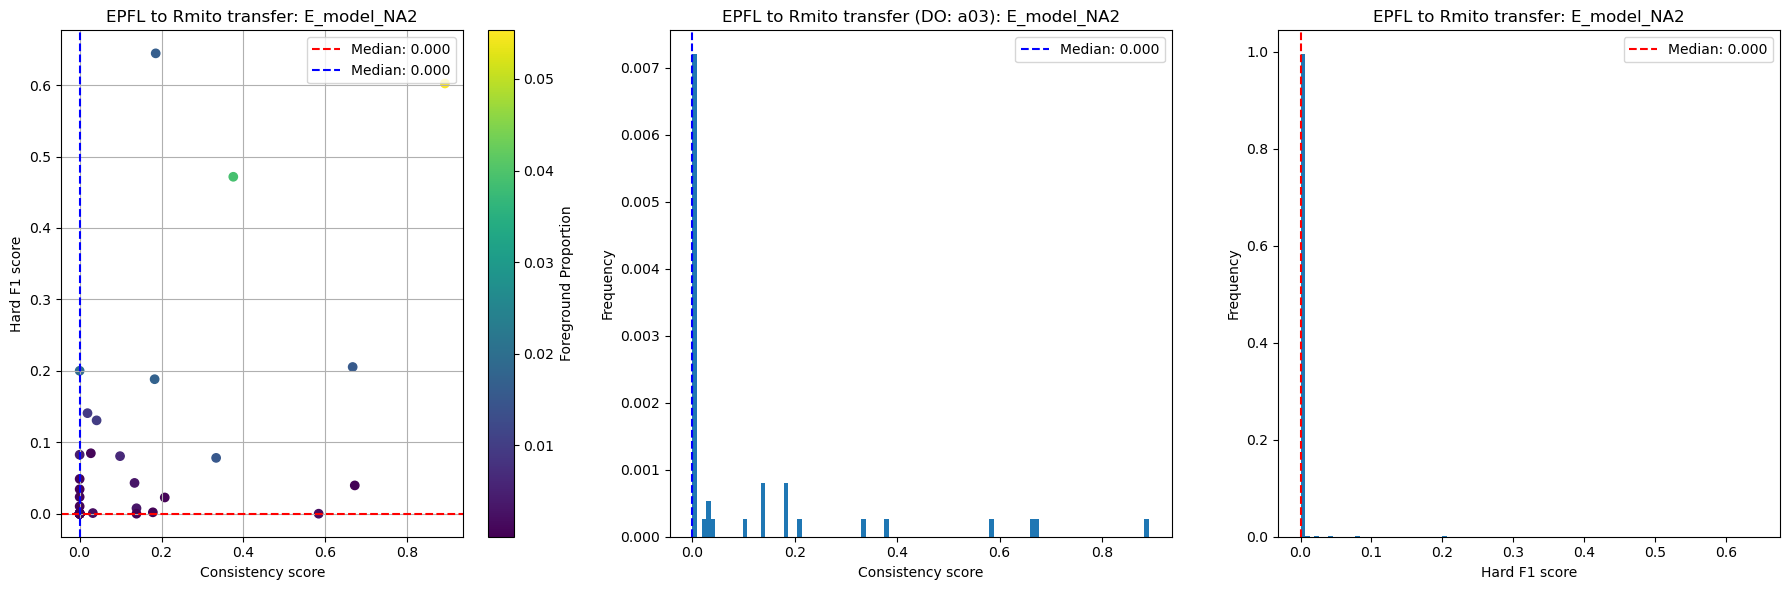

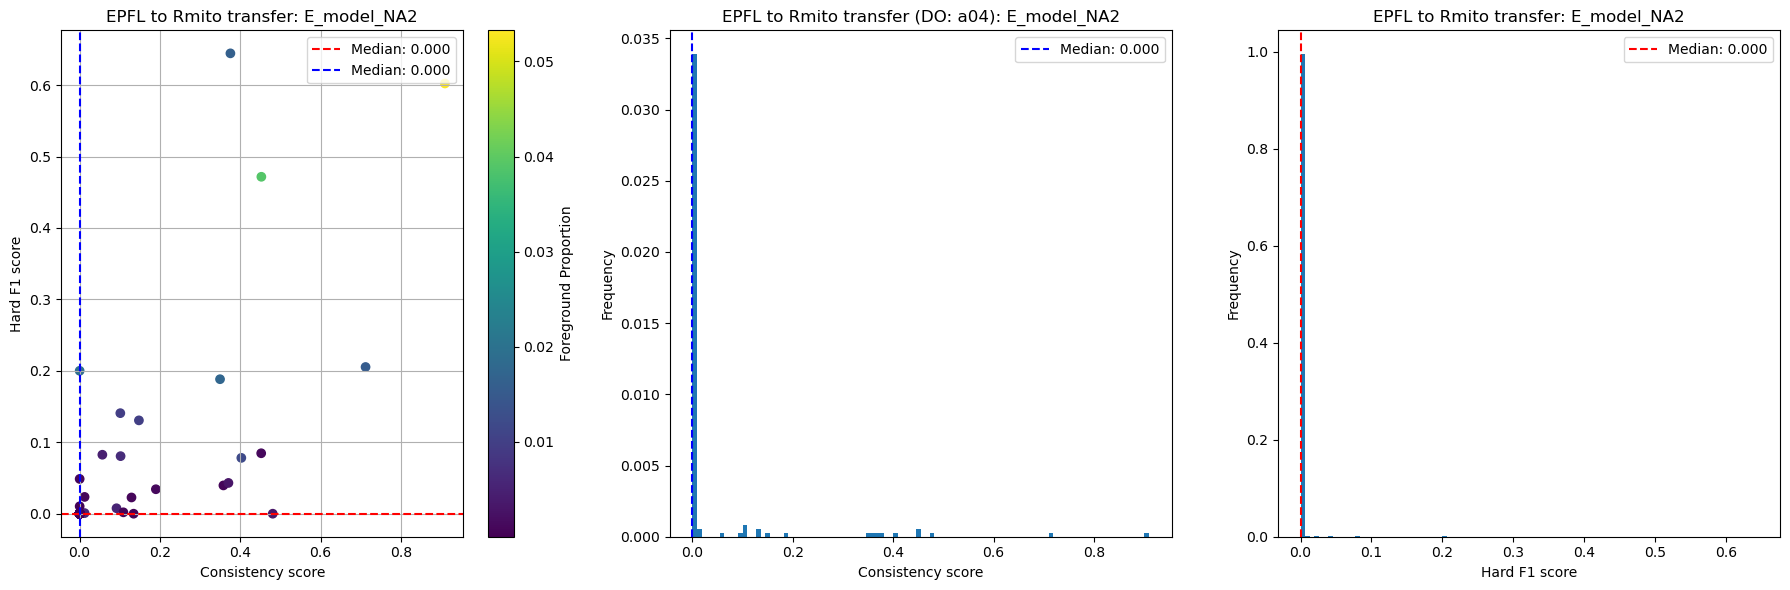

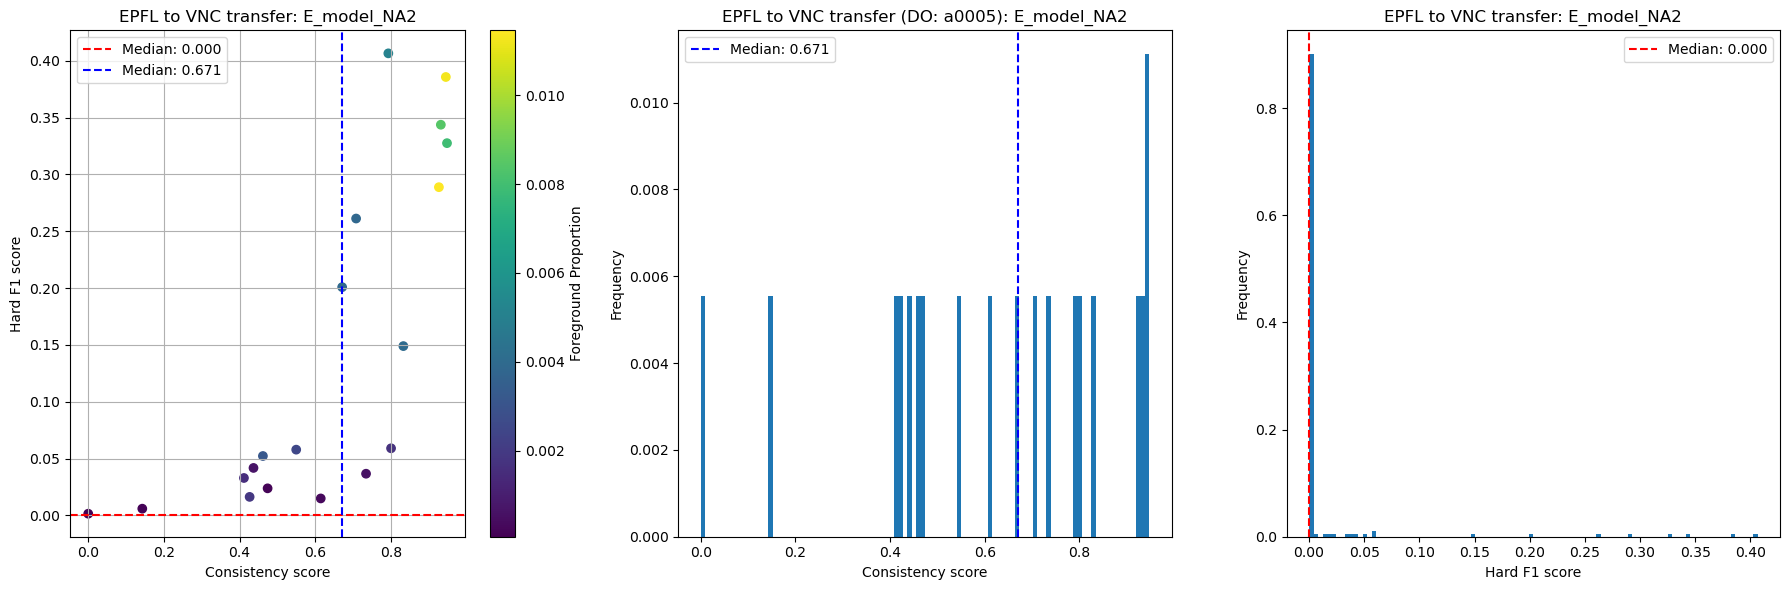

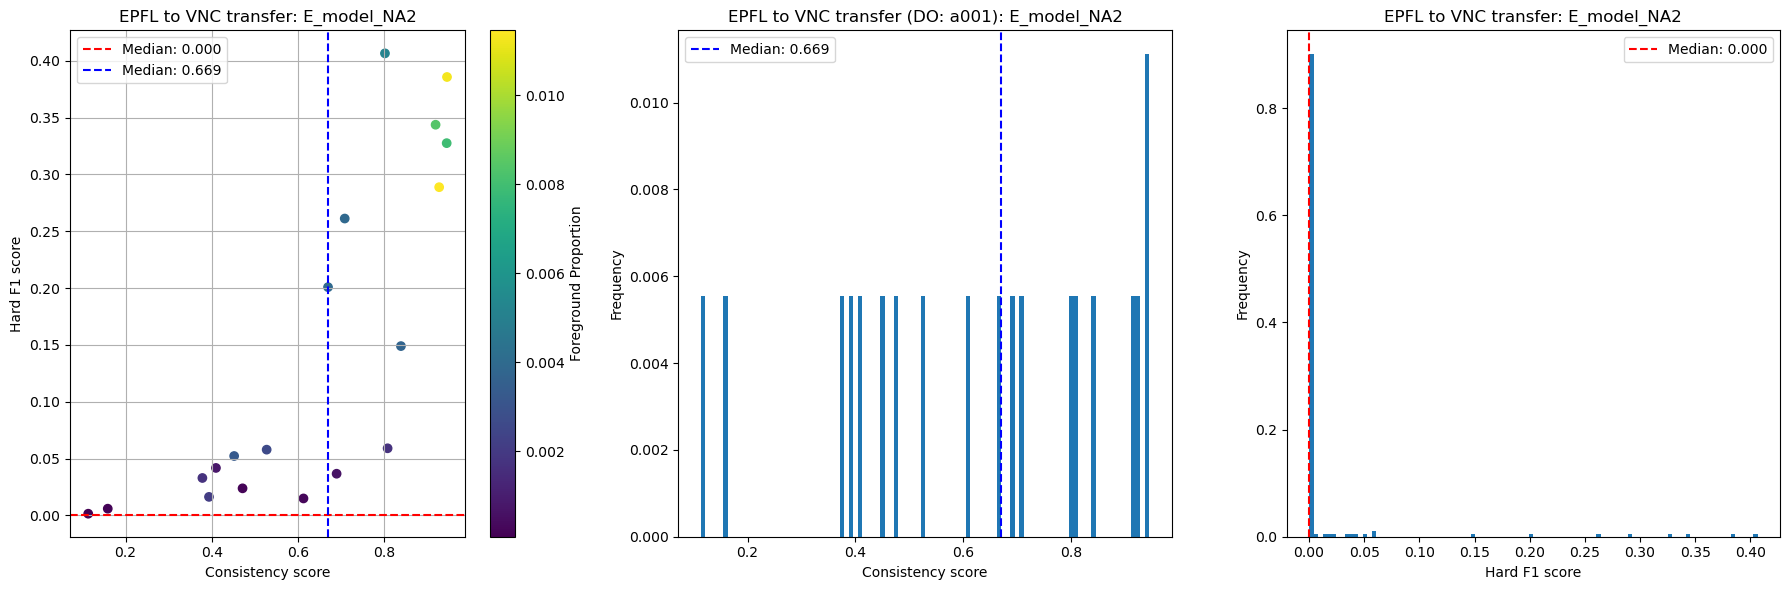

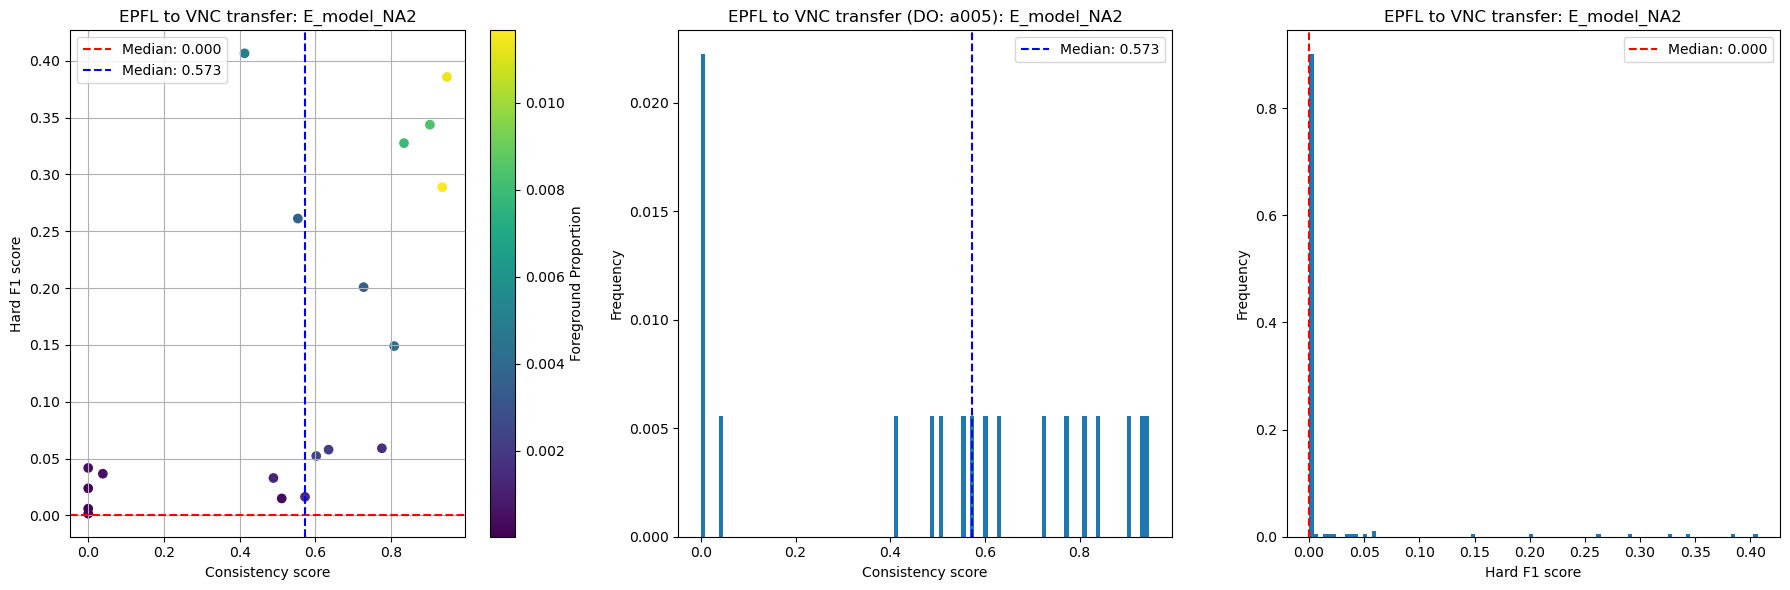

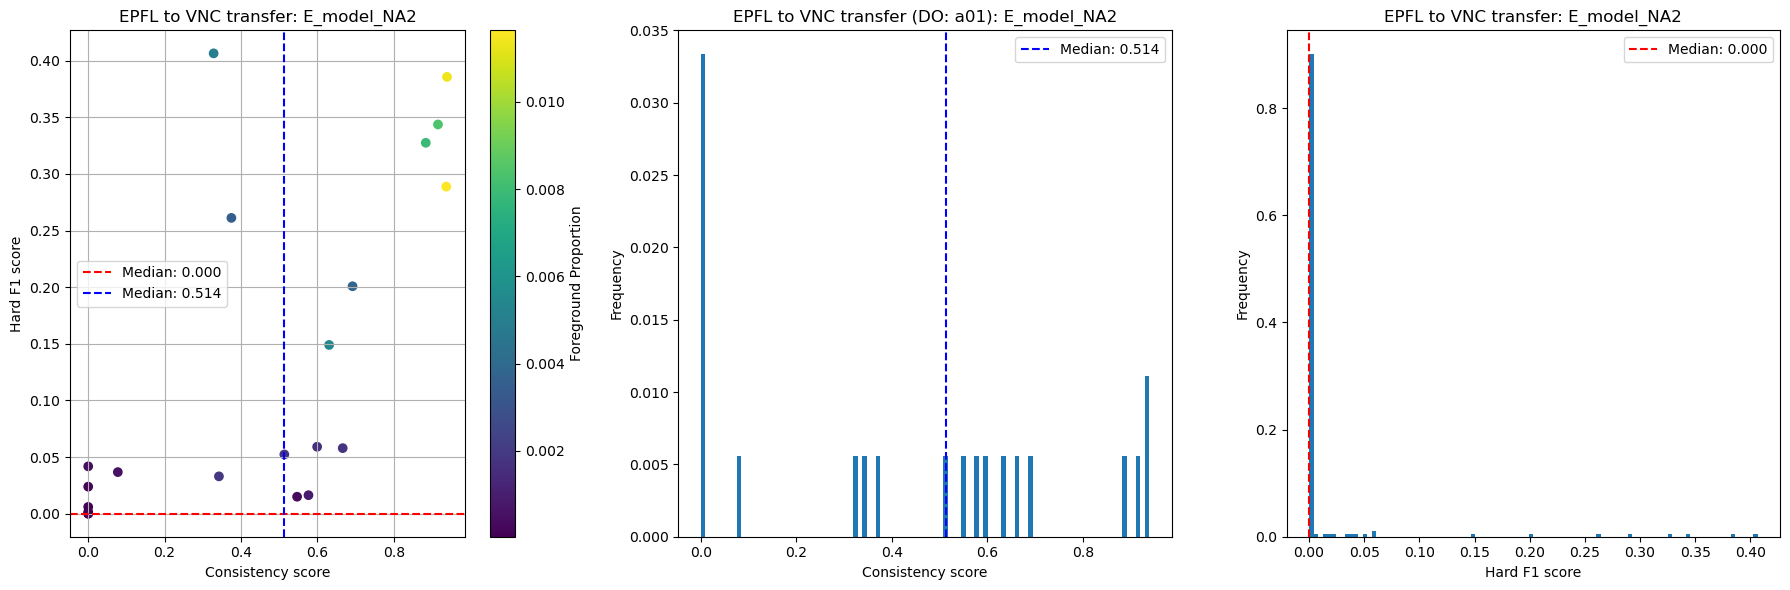

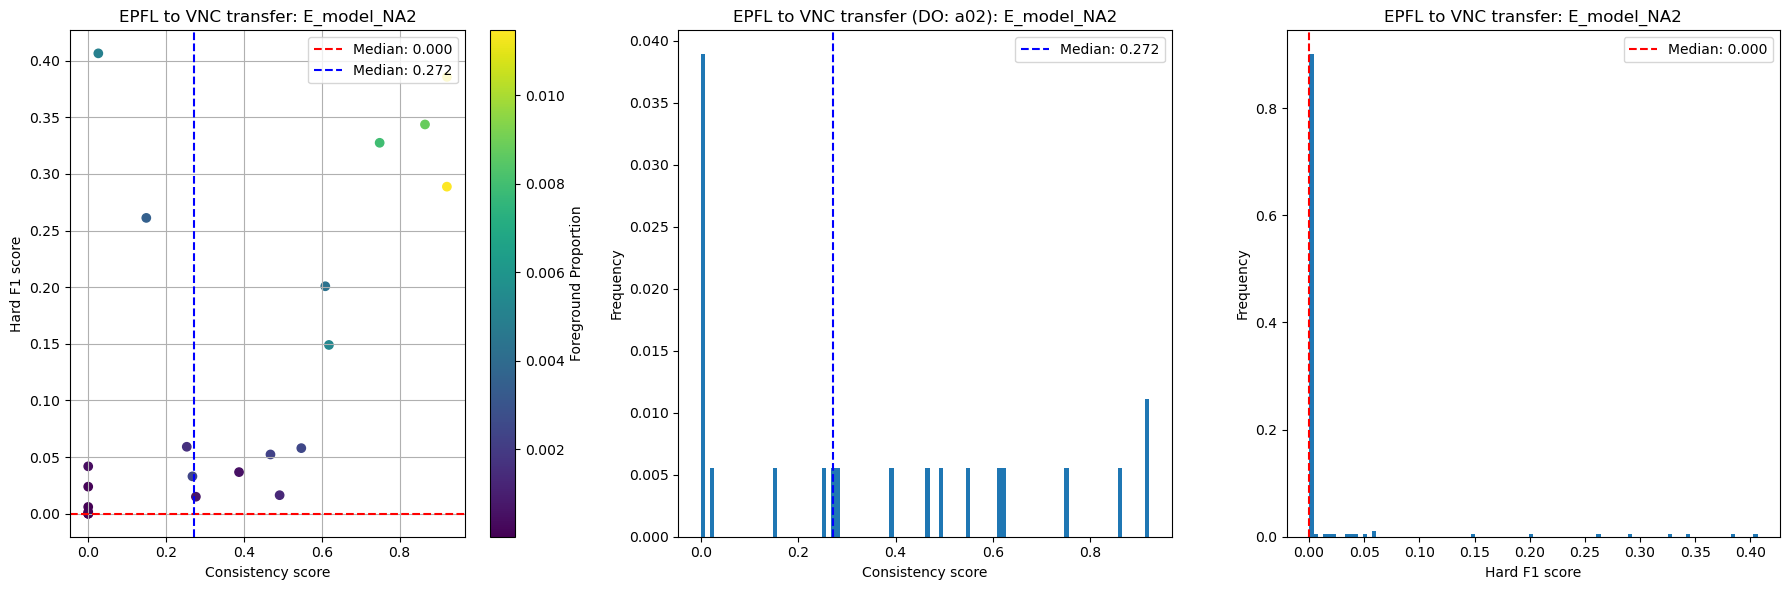

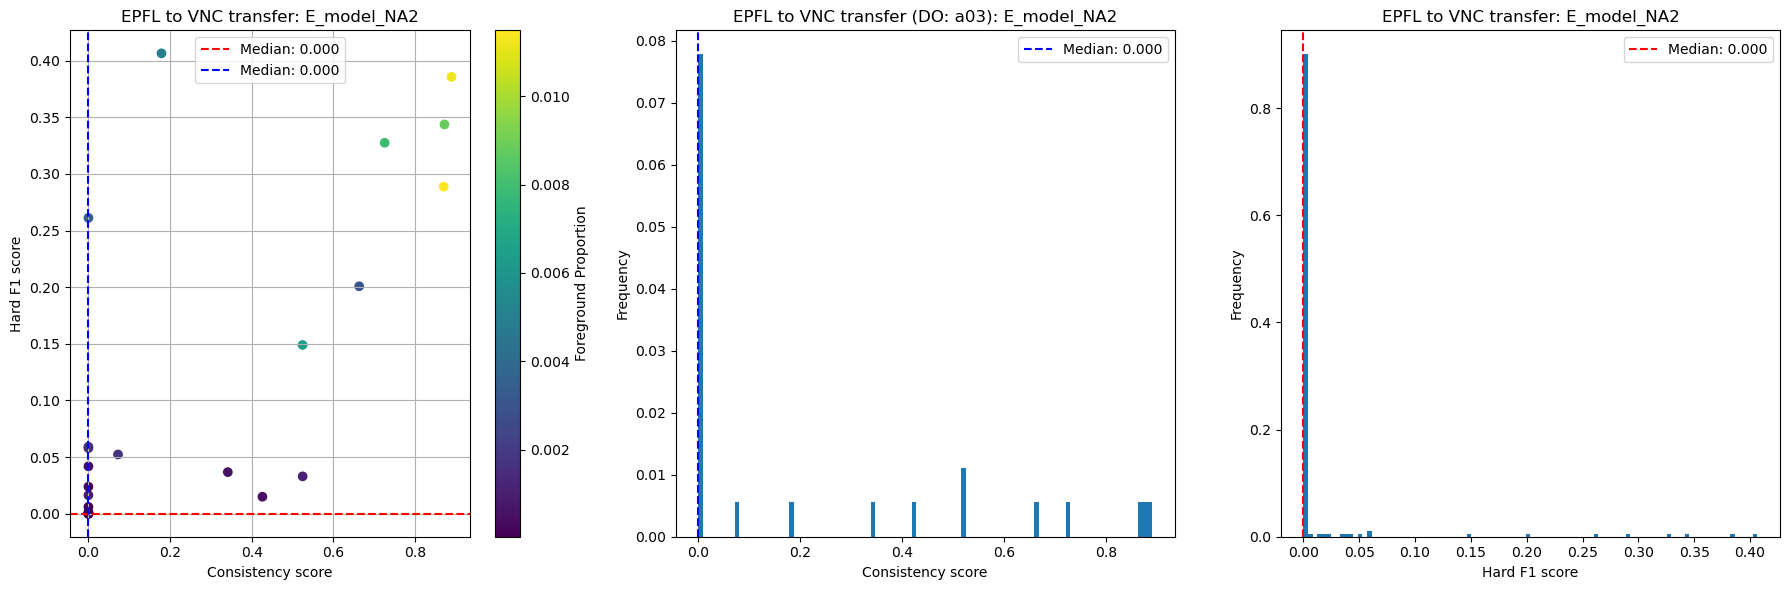

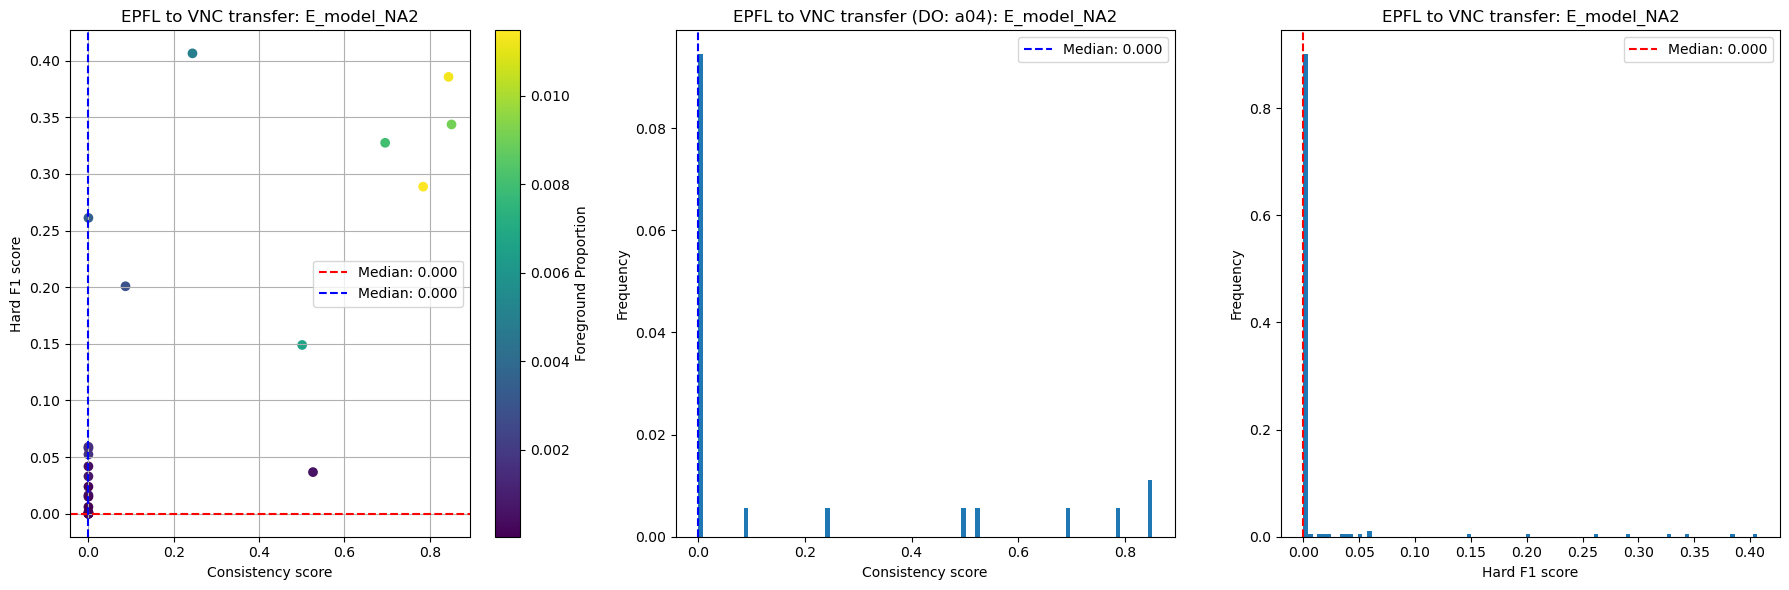

In [23]:
sources = {
    "EPFL": "E_model_NA2",
}
#targets = ["EPFL", "Hmito", "Rmito", "VNC"]
targets = ["Hmito", "Rmito", "VNC"]
result_folders = {
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}
consis_key = "EI_consis"
selected_alphas = ["a0005", "a001", "a005", "a01", "a02", "a03", "a04"]
#targets = ["VNC"]
# foreground_thresholds: Optional[Dict[str, float]] = {
#     "EPFL": 0.04,
#     "Hmito": 0.04,
#     "Rmito": 0.04,
#     "VNC": 0.02,
# }
foreground_thresholds: Optional[Dict[str, float]] = None

for source, model_name in sources.items():
    for target in targets:
        none_paths = get_output_paths(
            source, 
            target, 
            {"none": []}, 
            [None], 
            model_name, 
            "predictions", 
            result_folder =result_folders[target], 
            base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
        )
        assert len(none_paths) == 1, f"Expected one path for {source} to {target} transfer: {model_name}, found {len(paths)}"
        direct_pred_path: List[Path] = list(Path(none_paths[0]).glob("*.h5"))
        for i in range(len(direct_pred_path)):
            if "metric_summary" in direct_pred_path[i].name:
                _ = direct_pred_path.pop(i)
        eval_score_direct = load_h5(direct_pred_path[0], "hard_f1")[:,1]

        for perturbation_alpha in selected_alphas:

            DO_paths = get_output_paths(
                source, 
                target, 
                {"DO": [perturbation_alpha]}, 
                [None], 
                model_name, 
                "predictions", 
                result_folder = result_folders[target], 
                base_dir_path="/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
            )
            
            DO_pred_path: List[Path] = list(Path(DO_paths[0]).glob("*.h5"))
            for i in range(len(DO_pred_path)):
                if "metric_summary" in DO_pred_path[i].name:
                    _ = DO_pred_path.pop(i)
        
            consis_score_direct = load_h5(DO_pred_path[0], consis_key)
            consis_score_PP = np.nanmean(consis_score_direct, axis=tuple(range(1, consis_score_direct.ndim)))
            foreground_proportions = np.count_nonzero(~np.isnan(consis_score_direct), axis=(1,2))/consis_score_direct[0].size
            if foreground_thresholds is not None:
                sel_ids = np.where(foreground_proportions > foreground_thresholds[source])[0]
                consis_score_PP = consis_score_PP[sel_ids]
                eval_score_direct = eval_score_direct[sel_ids]
                foreground_proportions = foreground_proportions[sel_ids]
                eval_direct_median = np.nanmedian(eval_score_direct, axis=0)
                consis_median = np.nanmedian(consis_score_PP, axis=0)
            else:
                eval_direct_median = np.nanmedian(eval_score_direct, axis=0)
                consis_median = np.nanmedian(consis_score_PP, axis=0)
            _, axs = plt.subplots(1, 3, figsize=(18, 6))
            sc = axs[0].scatter(consis_score_PP, eval_score_direct, c=foreground_proportions, cmap='viridis')
            _ = axs[0].set_xlabel("Consistency score")
            _ = plt.colorbar(sc, ax=axs[0], label='Foreground Proportion')
            _ = axs[0].set_ylabel("Hard F1 score")
            _ = axs[0].grid()
            _ = axs[0].set_title(f"{source} to {target} transfer: {model_name}")
            _ = axs[0].axhline(eval_direct_median, color="red", linestyle="--", label="Median: {:.3f}".format(eval_direct_median))
            _ = axs[0].axvline(consis_median, color="blue", linestyle="--", label="Median: {:.3f}".format(consis_median))
            _ = axs[0].legend()
            _ = axs[1].hist(consis_score_PP, bins=100, weights=np.ones_like(consis_score_PP) / len(consis_score_PP))
            _ = axs[1].set_title(f"{source} to {target} transfer (DO: {perturbation_alpha}): {model_name}")
            _ = axs[1].set_xlabel("Consistency score")
            _ = axs[1].set_ylabel("Frequency")
            _ = axs[1].axvline(consis_median, color="blue", linestyle="--", label="Median: {:.3f}".format(consis_median))
            _ = axs[1].legend()
            _ = axs[2].hist(eval_score_direct, bins=100, weights=np.ones_like(eval_score_direct) / len(eval_score_direct))
            _ = axs[2].axvline(eval_direct_median, color="red", linestyle="--", label="Median: {:.3f}".format(eval_direct_median))
            _ = axs[2].legend()
            _ = axs[2].set_title(f"{source} to {target} transfer: {model_name}")
            _ = axs[2].set_xlabel("Hard F1 score")
            _ = axs[2].set_ylabel("Frequency")
            plt.tight_layout()
            plt.show()
        

In [25]:
EtoR_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_Rmito_gap/feature_perturbation_consistency/FP_3/E_model_NA2/norm_Normalize/DO_a005/predictions/test_converted_predictions.h5"
EtoR_preds = load_h5(EtoR_path, "predictions")
EtoR_patch_indexes = load_h5(EtoR_path, "patch_index")
EtoR_f1_Scores = load_h5(EtoR_path, "hard_f1")
EtoR_consis = load_h5(EtoR_path, "EI_consis")

In [29]:
print(EtoR_consis.shape)
consis_score_PP = np.nanmean(EtoR_consis, axis=tuple(range(1, EtoR_consis.ndim)))
print(consis_score_PP.shape)

(3750, 256, 256)
(3750,)


/tmp/ipykernel_4149064/2047448455.py:2: RuntimeWarning: Mean of empty slice
  consis_score_PP = np.nanmean(EtoR_consis, axis=tuple(range(1, EtoR_consis.ndim)))


In [31]:
num_nan = np.isnan(consis_score_PP).sum()
print(f"Number of NaN entries in consis_score_PP: {num_nan}")

Number of NaN entries in consis_score_PP: 3723


In [27]:
ids_zero = np.where(EtoR_f1_Scores[:, 1] == 0)[0]
print(f"Number of patches with zero F1 score: {len(ids_zero)}")

Number of patches with zero F1 score: 3728


In [32]:
EtoH_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_Hmito_gap/feature_perturbation_consistency/FP_3/E_model_NA2/norm_Normalize/DO_a005/predictions/test_converted_predictions.h5"
EtoH_preds = load_h5(EtoH_path, "predictions")
EtoH_patch_indexes = load_h5(EtoH_path, "patch_index")
EtoH_f1_Scores = load_h5(EtoH_path, "hard_f1")
EtoH_consis = load_h5(EtoH_path, "EI_consis")

In [33]:
print(EtoH_consis.shape)
EtoH_consis_score_PP = np.nanmean(EtoH_consis, axis=tuple(range(1, EtoH_consis.ndim)))
print(EtoH_consis_score_PP.shape)

(3750, 256, 256)
(3750,)


/tmp/ipykernel_4149064/2475626679.py:2: RuntimeWarning: Mean of empty slice
  EtoH_consis_score_PP = np.nanmean(EtoH_consis, axis=tuple(range(1, EtoH_consis.ndim)))


In [35]:
num_nan = np.isnan(EtoH_consis_score_PP).sum()
print(f"Number of NaN entries in EtoH_consis_score_PP: {num_nan}")
ids_zero = np.where(EtoH_f1_Scores[:, 1] == 0)[0]
print(f"Number of patches with zero F1 score: {len(ids_zero)}")

Number of NaN entries in EtoH_consis_score_PP: 3164
Number of patches with zero F1 score: 3236


In [36]:
EtoV_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_VNC_gap/feature_perturbation_consistency/FP_3/E_model_NA2/norm_Normalize/DO_a005/predictions/source_mitoEM_true_predictions.h5"
EtoV_preds = load_h5(EtoV_path, "predictions")
EtoV_patch_indexes = load_h5(EtoV_path, "patch_index")
EtoV_f1_Scores = load_h5(EtoV_path, "hard_f1")
EtoV_consis = load_h5(EtoV_path, "EI_consis")

In [38]:
print(EtoV_consis.shape)
EtoV_consis_score_PP = np.nanmean(EtoV_consis, axis=tuple(range(1, EtoV_consis.ndim)))
print(EtoV_consis_score_PP.shape)
num_nan = np.isnan(EtoV_consis_score_PP).sum()
print(f"Number of NaN entries in EtoV_consis_score_PP: {num_nan}")
ids_zero = np.where(EtoV_f1_Scores[:, 1] == 0)[0]
print(f"Number of patches with zero F1 score: {len(ids_zero)}")

(180, 256, 256)
(180,)
Number of NaN entries in EtoV_consis_score_PP: 161
Number of patches with zero F1 score: 165


/tmp/ipykernel_4149064/3605060776.py:2: RuntimeWarning: Mean of empty slice
  EtoV_consis_score_PP = np.nanmean(EtoV_consis, axis=tuple(range(1, EtoV_consis.ndim)))
